In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplot2tikz
import numpy as np

In [3]:
df = pd.read_csv('../log/20260106.csv', header = None, names = ['dataset', 'train_fitness', 'test_fitness',  'parameters',
                                                        'depth', 'width', 'test_brmse', 'test_mcc', 'test_bce','seed', 'generation', 'timing'])

In [7]:
df['dataset'].value_counts()

dataset
brain_tumor_rn18_10_brmse     60030
brain_tumor_rn18_50_brmse     60030
brain_tumor_rn18_100_brmse    60030
brain_tumor_rn18_250_brmse    60030
brain_tumor_rn18_500_brmse    60030
brain_tumor_rn34_10_brmse     60030
brain_tumor_rn34_50_brmse     60030
brain_tumor_rn34_100_brmse    60030
brain_tumor_rn34_250_brmse    60030
brain_tumor_rn34_500_brmse    60030
brain_tumor_rn50_10_brmse     60030
brain_tumor_rn50_50_brmse     60030
brain_tumor_rn50_100_brmse    60030
brain_tumor_rn50_250_brmse    60030
brain_tumor_rn50_500_brmse    60030
brain_tumor_rn18_10_bce       36426
Name: count, dtype: int64

In [24]:
baseline_nn = pd.read_csv('../log/baseline_dropout_20260108.csv', header = None, names = ['dataset', 'test_brmse', 'test_bce',  'test_mcc',
                                                                                          'seed', 'generation', 'timing'])

In [9]:
fs_baseline = pd.read_csv("../log/20260105_fs_baseline.csv")

In [10]:
fs_baseline.head()

,dataset,seed,train_size,test_size,n_classes,protonet_train_mcc,protonet_test_mcc,maml_train_mcc,maml_test_mcc,transductive_train_mcc,transductive_test_mcc
0,brain_tumor_rn18_10,0,10,2990,2,1.000000,0.488236,1.000000,0.457665,1.0,0.569117
1,brain_tumor_rn18_50,1,50,2950,2,0.762444,0.394079,0.922958,0.520232,1.0,0.593223
2,brain_tumor_rn18_50,0,50,2950,2,0.840000,0.617886,1.000000,0.626846,1.0,0.673309
3,brain_tumor_rn18_50,2,50,2950,2,0.880705,0.533431,1.000000,0.561245,1.0,0.592960
4,brain_tumor_rn18_50,4,50,2950,2,0.960769,0.595497,1.000000,0.527703,1.0,0.619168


In [11]:
baseline_nn.head()

,dataset,test_brmse,test_bce,test_mcc,seed,generation,timing
0,brain_tumor_rn18_10,0.501007,0.695167,-0.0,13,2000,873.708245
1,brain_tumor_rn18_10,0.500066,0.693279,-0.0,12,2000,880.564681
2,brain_tumor_rn18_10,0.500201,0.693550,-0.0,19,2000,883.407889
3,brain_tumor_rn18_10,0.500191,0.693529,-0.0,27,2000,891.837555
4,brain_tumor_rn18_10,0.500455,0.694058,-0.0,22,2000,895.768891


In [12]:
df.head()

,dataset,train_fitness,test_fitness,parameters,depth,width,test_brmse,test_mcc,test_bce,seed,generation,timing
0,brain_tumor_rn18_10_brmse,0.414233,0.493743,8671,1,4,0.493743,-0.190845,0.680545,3,0,20.579829
1,brain_tumor_rn18_10_brmse,0.414218,0.493746,9230,2,4,0.493746,-0.190845,0.680552,3,1,0.139288
2,brain_tumor_rn18_10_brmse,0.410844,0.476272,8407,1,3,0.476272,-0.350728,0.645865,2,0,20.770404
3,brain_tumor_rn18_10_brmse,0.413301,0.483298,6556,1,4,0.483298,-0.352070,0.659972,5,0,20.327159
4,brain_tumor_rn18_10_brmse,0.410844,0.476272,8407,1,3,0.476272,-0.350728,0.645865,2,1,0.149143


In [13]:
df[df['generation'] == 1000][['dataset', 'depth', 'width' ]].groupby('dataset').median().to_dict()

{'depth': {'brain_tumor_rn18_100_brmse': 468.5,
  'brain_tumor_rn18_10_bce': 476.0,
  'brain_tumor_rn18_10_brmse': 469.0,
  'brain_tumor_rn18_250_brmse': 474.0,
  'brain_tumor_rn18_500_brmse': 475.0,
  'brain_tumor_rn18_50_brmse': 462.5,
  'brain_tumor_rn34_100_brmse': 468.5,
  'brain_tumor_rn34_10_brmse': 466.5,
  'brain_tumor_rn34_250_brmse': 467.5,
  'brain_tumor_rn34_500_brmse': 474.0,
  'brain_tumor_rn34_50_brmse': 466.5,
  'brain_tumor_rn50_100_brmse': 477.0,
  'brain_tumor_rn50_10_brmse': 469.5,
  'brain_tumor_rn50_250_brmse': 476.0,
  'brain_tumor_rn50_500_brmse': 483.5,
  'brain_tumor_rn50_50_brmse': 470.0},
 'width': {'brain_tumor_rn18_100_brmse': 3.0,
  'brain_tumor_rn18_10_bce': 3.0,
  'brain_tumor_rn18_10_brmse': 3.0,
  'brain_tumor_rn18_250_brmse': 3.0,
  'brain_tumor_rn18_500_brmse': 4.0,
  'brain_tumor_rn18_50_brmse': 3.0,
  'brain_tumor_rn34_100_brmse': 3.0,
  'brain_tumor_rn34_10_brmse': 3.0,
  'brain_tumor_rn34_250_brmse': 3.0,
  'brain_tumor_rn34_500_brmse': 3.0,
  

In [14]:
df['test_mcc'] = df.test_mcc.apply(lambda x: -1.0*x)

In [15]:
df['train_fitness'] = df.train_fitness.apply(lambda x: -1.0*x if x < 0 else x)
df['test_fitness'] = df.test_fitness.apply(lambda x: -1.0*x if x < 0 else x)

In [16]:
df['train_size'] = df.dataset.apply(lambda x: x.split('_')[-2])
df['train_metric'] = df.dataset.apply(lambda x: x.split('_')[-1])
df['encoding'] = df.dataset.apply(lambda x: x.split('_')[-3])
df['dataset'] = df.dataset.apply(lambda x: '_'.join(x.split('_')[:-3]))

In [17]:
df['train_size'] = df['train_size'].astype(int)

In [26]:
baseline_nn['train_size'] = baseline_nn.dataset.apply(lambda x: x.split('_')[-1])
baseline_nn['encoding'] = baseline_nn.dataset.apply(lambda x: x.split('_')[-2])
baseline_nn['dataset'] = baseline_nn.dataset.apply(lambda x: '_'.join(x.split('_')[:-2]))

In [27]:
baseline_nn['train_size']  = baseline_nn['train_size'].astype(int)

In [20]:
# Group by dataset, train_size, encoding, train_metric
grouped = df.groupby(['dataset', 'train_size', 'encoding', 'train_metric'])[['test_brmse', 'test_mcc', 'test_bce']].mean()

In [14]:
grouped

test_brmse  test_mcc  test_bce
dataset      train_size encoding train_metric                                
brain_tumor  10         rn18     bce             0.492677  0.173578  0.678641
                                 brmse           0.492505  0.176511  0.678312
                                 mcc             0.495604  0.117380  0.684332
                        rn34     bce             0.492640  0.212416  0.678920
                                 brmse           0.492618  0.216847  0.678851
...                                                   ...       ...       ...
tuberculosis 500        rn34     brmse           0.440378  0.443864  0.572930
                                 mcc             0.453791  0.411133  0.599673
                        rn50     bce             0.435588  0.485682  0.564409
                                 brmse           0.436506  0.503559  0.566464
                                 mcc             0.453344  0.444350  0.599128

[90 rows x 3 columns]

In [29]:
datasets

array(['brain_tumor'], dtype=object)

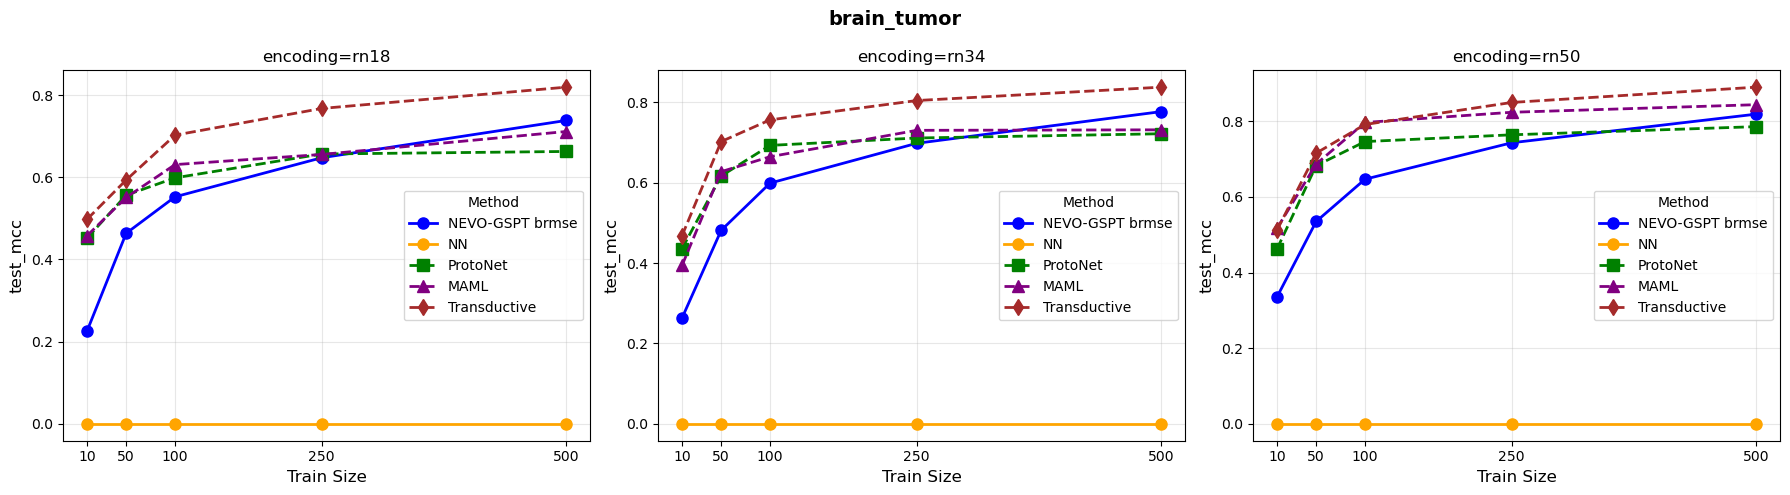

In [42]:
# First, let's add the few-shot baseline methods to the plot
# The fs_baseline df has columns like protonet_test_mcc, maml_test_mcc, transductive_test_mcc

# Colors for the different methods
colors = {'brmse': 'blue', 'bce': 'red'}
fs_colors = {'protonet': 'green', 'maml': 'purple', 'transductive': 'brown'}

# Parameter to choose metric
METRIC = 'test_mcc'

datasets = df['dataset'].unique()
encodings = df['encoding'].unique()

for dataset in datasets:
    n_encodings = len([e for e in encodings if len(df[(df['dataset'] == dataset) & (df['encoding'] == e)]) > 0])
    
    if n_encodings == 0:
        continue
    
    fig, axes = plt.subplots(1, n_encodings, figsize=(6 * n_encodings, 5), squeeze=False)
    fig.suptitle(f'{dataset}', fontsize=14, fontweight='bold')
    
    plot_idx = 0
    for encoding in encodings:
        subset = df[(df['dataset'] == dataset) & (df['encoding'] == encoding) & (df['generation'] == 1000)]
        
        if len(subset) == 0:
            continue
        
        ax = axes[0, plot_idx]
        
        # Plot BRMSE data
        for train_metric in ['brmse']:
            data = subset[subset['train_metric'] == train_metric]
            
            if len(data) == 0:
                continue
            
            grouped = data.groupby('train_size')[METRIC].median().sort_index()
            color = colors.get(train_metric, 'gray')
            ax.plot(grouped.index, grouped.values, 'o-', color=color, label='NEVO-GSPT ' + train_metric.lower(), linewidth=2, markersize=8)
        
        # Plot NN baseline
        subset_nn = baseline_nn[(baseline_nn['dataset'] == dataset) & (baseline_nn['encoding'] == encoding)]
        grouped_nn = subset_nn.groupby('train_size')[METRIC].median().sort_index()
        ax.plot(grouped_nn.index, grouped_nn.values, 'o-', color='orange', label='NN', linewidth=2, markersize=8)
        
        # Plot few-shot baselines from fs_baseline
        # Filter fs_baseline for this dataset (assuming dataset names match or need mapping)
        # You may need to adjust the dataset name matching
        fs_subset = fs_baseline[
            (fs_baseline['dataset'].str.contains(dataset, case=False)) & 
            (fs_baseline['dataset'].str.contains(encoding, case=False))
        ]        
        if len(fs_subset) > 0:
            # Plot ProtoNet
            grouped_proto = fs_subset.groupby('train_size')['protonet_test_mcc'].median().sort_index()
            ax.plot(grouped_proto.index, grouped_proto.values, 's--', color=fs_colors['protonet'], 
                    label='ProtoNet', linewidth=2, markersize=8)
            
            # Plot MAML
            grouped_maml = fs_subset.groupby('train_size')['maml_test_mcc'].median().sort_index()
            ax.plot(grouped_maml.index, grouped_maml.values, '^--', color=fs_colors['maml'], 
                    label='MAML', linewidth=2, markersize=8)
            
            # Plot Transductive
            grouped_trans = fs_subset.groupby('train_size')['transductive_test_mcc'].median().sort_index()
            ax.plot(grouped_trans.index, grouped_trans.values, 'd--', color=fs_colors['transductive'], 
                    label='Transductive', linewidth=2, markersize=8)
        
        ax.set_xlabel('Train Size', fontsize=12)
        ax.set_ylabel(METRIC, fontsize=12)
        ax.set_title(f'encoding={encoding}', fontsize=12)
        ax.legend(title='Method')
        ax.set_xticks(sorted(subset['train_size'].unique()))
        ax.grid(True, alpha=0.3)
        
        plot_idx += 1
    
    plt.tight_layout()
    plt.show()

In [40]:
fs_baseline

,dataset,seed,train_size,test_size,n_classes,protonet_train_mcc,protonet_test_mcc,maml_train_mcc,maml_test_mcc,transductive_train_mcc,transductive_test_mcc
0,brain_tumor_rn18_10,0,10,2990,2,1.000000,0.488236,1.000000,0.457665,1.000000,0.569117
1,brain_tumor_rn18_50,1,50,2950,2,0.762444,0.394079,0.922958,0.520232,1.000000,0.593223
2,brain_tumor_rn18_50,0,50,2950,2,0.840000,0.617886,1.000000,0.626846,1.000000,0.673309
3,brain_tumor_rn18_50,2,50,2950,2,0.880705,0.533431,1.000000,0.561245,1.000000,0.592960
4,brain_tumor_rn18_50,4,50,2950,2,0.960769,0.595497,1.000000,0.527703,1.000000,0.619168
...,...,...,...,...,...,...,...,...,...,...,...
145,tuberculosis_rn50_250,4,250,412,2,0.695031,0.632283,0.840471,0.684736,1.000000,0.588842
146,tuberculosis_rn50_500,0,500,162,2,0.657658,0.633113,0.783000,0.743755,1.000000,0.668142
147,tuberculosis_rn50_500,2,500,162,2,0.684786,0.559997,0.781561,0.661303,0.991998,0.621590
148,tuberculosis_rn50_500,3,500,162,2,0.674495,0.684675,0.776186,0.681125,1.000000,0.629878


KeyError: 'Column not found: protonet_test_bce'

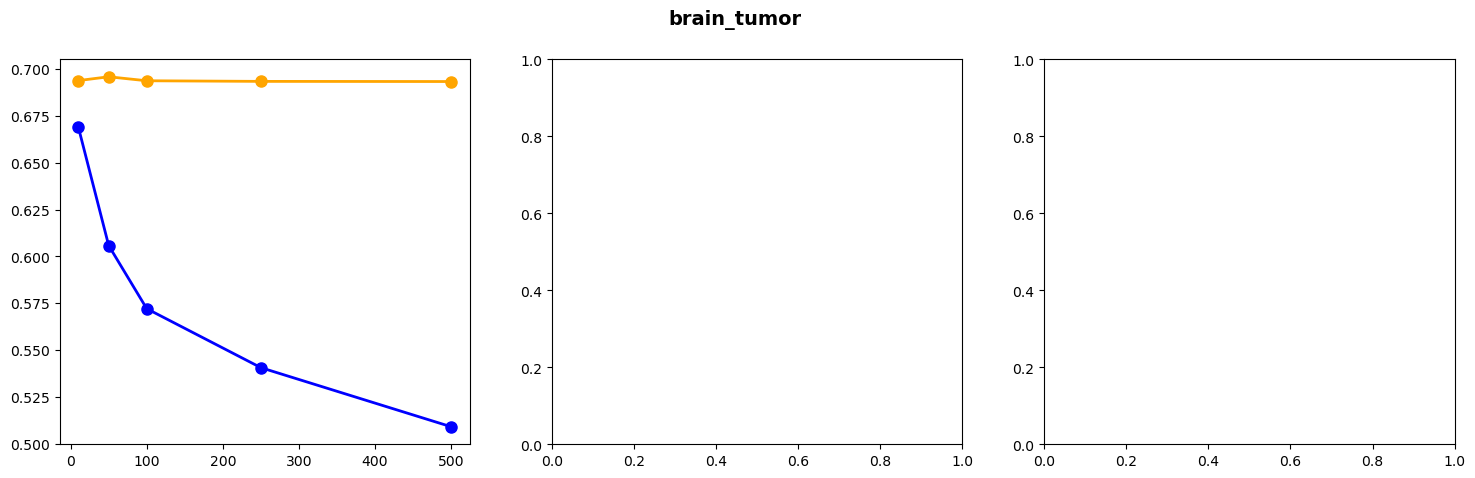

In [39]:
# First, let's add the few-shot baseline methods to the plot
# The fs_baseline df has columns like protonet_test_mcc, maml_test_mcc, transductive_test_mcc

# Colors for the different methods
colors = {'brmse': 'blue', 'bce': 'red'}
fs_colors = {'protonet': 'green', 'maml': 'purple', 'transductive': 'brown'}

# Parameter to choose metric
METRIC = 'test_bce'

datasets = df['dataset'].unique()
encodings = df['encoding'].unique()

for dataset in datasets:
    n_encodings = len([e for e in encodings if len(df[(df['dataset'] == dataset) & (df['encoding'] == e)]) > 0])
    
    if n_encodings == 0:
        continue
    
    fig, axes = plt.subplots(1, n_encodings, figsize=(6 * n_encodings, 5), squeeze=False)
    fig.suptitle(f'{dataset}', fontsize=14, fontweight='bold')
    
    plot_idx = 0
    for encoding in encodings:
        subset = df[(df['dataset'] == dataset) & (df['encoding'] == encoding) & (df['generation'] == 1000)]
        
        if len(subset) == 0:
            continue
        
        ax = axes[0, plot_idx]
        
        # Plot BRMSE data
        for train_metric in ['brmse']:
            data = subset[subset['train_metric'] == train_metric]
            
            if len(data) == 0:
                continue
            
            grouped = data.groupby('train_size')[METRIC].median().sort_index()
            color = colors.get(train_metric, 'gray')
            ax.plot(grouped.index, grouped.values, 'o-', color=color, label='NEVO-GSPT ' + train_metric.lower(), linewidth=2, markersize=8)
        
        # Plot NN baseline
        subset_nn = baseline_nn[(baseline_nn['dataset'] == dataset) & (baseline_nn['encoding'] == encoding)]
        grouped_nn = subset_nn.groupby('train_size')[METRIC].median().sort_index()
        ax.plot(grouped_nn.index, grouped_nn.values, 'o-', color='orange', label='NN', linewidth=2, markersize=8)
        
        # Plot few-shot baselines from fs_baseline
        # Filter fs_baseline for this dataset (assuming dataset names match or need mapping)
        # You may need to adjust the dataset name matching
        fs_subset = fs_baseline[fs_baseline['dataset'].str.contains(dataset.split('_')[0], case=False)]
        
        if len(fs_subset) > 0:
            # Plot ProtoNet
            grouped_proto = fs_subset.groupby('train_size')['protonet_'+METRIC].median().sort_index()
            ax.plot(grouped_proto.index, grouped_proto.values, 's--', color=fs_colors['protonet'], 
                    label='ProtoNet', linewidth=2, markersize=8)
            
            # Plot MAML
            grouped_maml = fs_subset.groupby('train_size')['maml_'+METRIC].median().sort_index()
            ax.plot(grouped_maml.index, grouped_maml.values, '^--', color=fs_colors['maml'], 
                    label='MAML', linewidth=2, markersize=8)
            
            # Plot Transductive
            grouped_trans = fs_subset.groupby('train_size')['transductive_'+METRIC].median().sort_index()
            ax.plot(grouped_trans.index, grouped_trans.values, 'd--', color=fs_colors['transductive'], 
                    label='Transductive', linewidth=2, markersize=8)
        
        ax.set_xlabel('Train Size', fontsize=12)
        ax.set_ylabel(METRIC, fontsize=12)
        ax.set_title(f'encoding={encoding}', fontsize=12)
        ax.legend(title='Method')
        ax.set_xticks(sorted(subset['train_size'].unique()))
        ax.grid(True, alpha=0.3)
        
        plot_idx += 1
    
    plt.tight_layout()
    plt.show()